# Modelo proposto pelas IAs CLAUDE E CHATGPT
## Identificação de Compressão de Volatilidade

Este modelo, é a tentantiva de sinalizar oportunidades de  entradas quando a volatildiade esta baixa.
Sugestão de montagem de Travas, Short Butterfly, Long Strangles, Straddle  ,  Iron Condor Reverso
Acreditando que as opçoes estao baratas, e a vol ira aumentar, compramos essas estruturas

## FUNÇÕES - Modelo Chat GPT

In [ ]:
# Importar Todas as Funções
from OPCOES_ExplosaoVol_CLAUDE_GPT_novo import *

# Rodar Funções

Baixando BBSE3.SA...


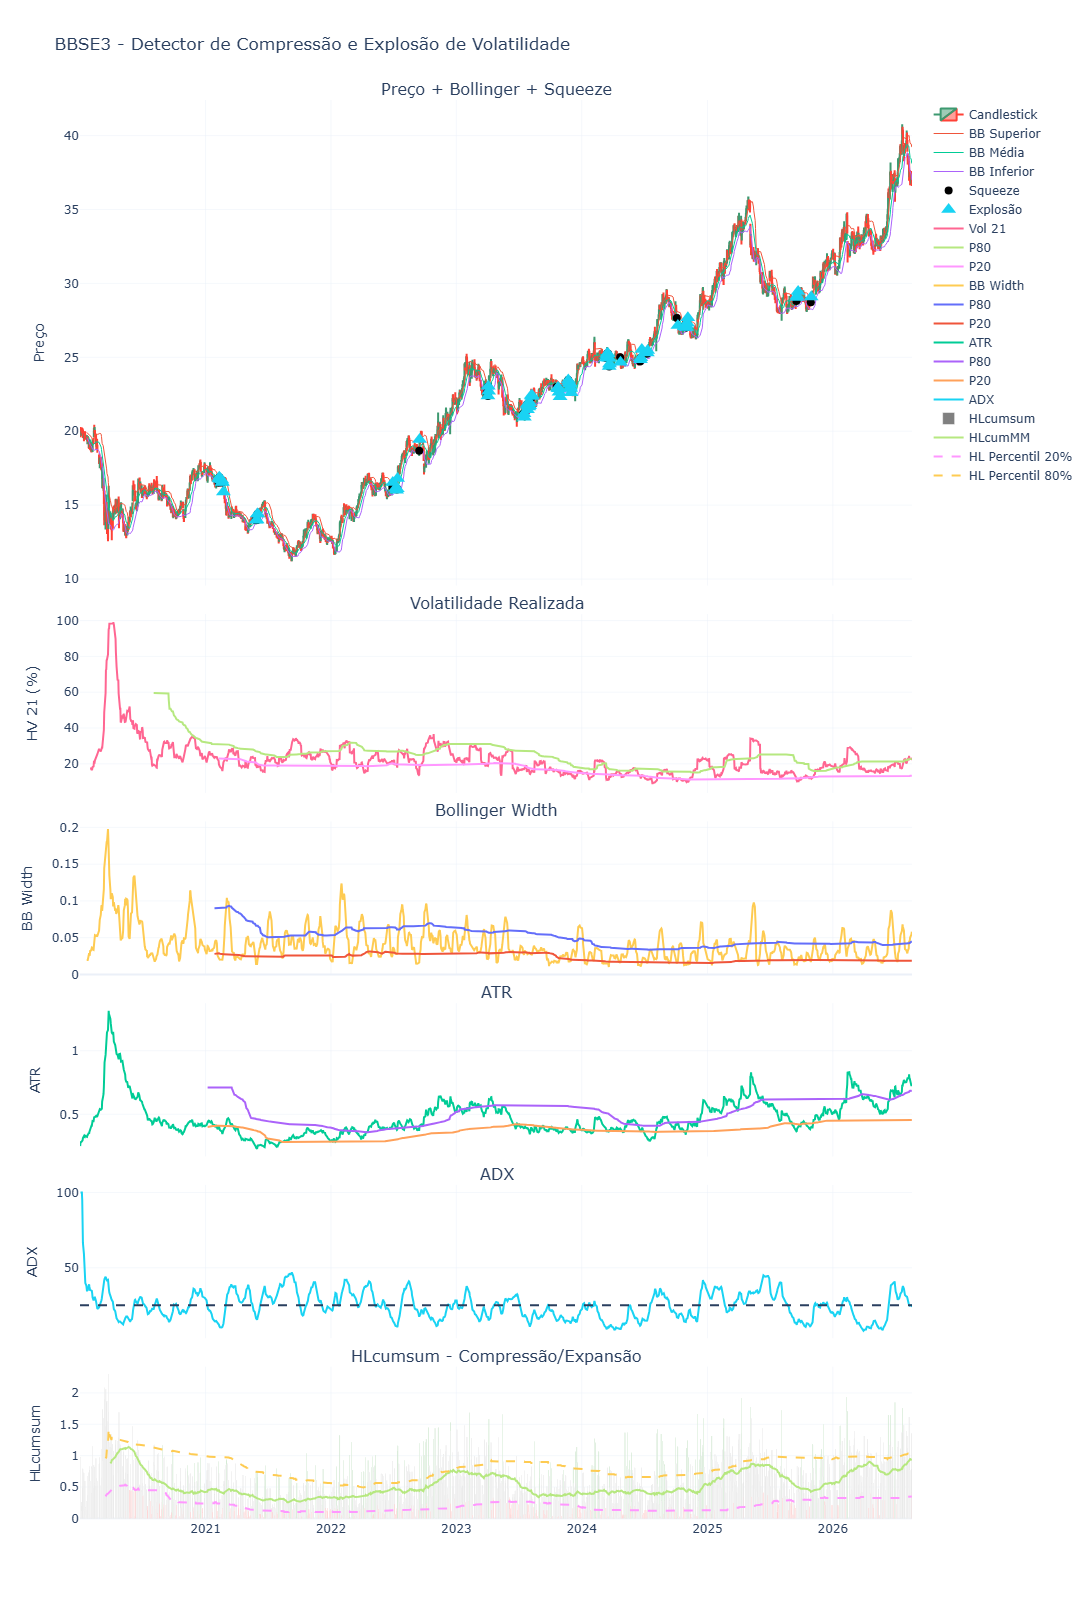

In [15]:
# Importar Todas as Funções
from OPCOES_ExplosaoVol_CLAUDE_GPT_novo import *
# coletar ticker =======================================================
from pathlib import Path
import sys

import MetaTrader5 as mt5
import multiprocessing
import os
import time
from concurrent.futures import ThreadPoolExecutor

# Pasta raiz do projeto (um nível acima de Testes)
projeto = Path.cwd().parent

if str(projeto) not in sys.path:
    sys.path.insert(0, str(projeto))


tf = mt5.TIMEFRAME_D1 # TIME FRAME
cotacoes = 3000
NaN_Maximo = 0

tiker = 'BBSE3'

# ==========================================================
# PARÂMETROS QUE DEFINEM AS ENTRADAS (SQUEEZE / EXPLOSÃO)
# Altere os valores abaixo para testar outras configurações.
# ==========================================================
VOL21_PERCENTIL     = 0.15   # percentil mínimo de VOL_21 (0 a 1)
VOL21_JANELA        = 252    # janela (candles) do rolling do percentil
BB_WIDTH_PERCENTIL  = 0.15   # percentil mínimo de BB Width (0 a 1)
BB_WIDTH_JANELA     = 252    # janela (candles) do rolling do percentil
ADX_MINIMO          = 18     # ADX mínimo para squeeze (trend forte)
ATR_CONTRACAO_MULT  = 0.0    # divisor do ATR p/ sinal de explosão (contração)

# COELTAR COM YFINANCE ===================================================
df = carregar_dados(ticker= tiker+".SA", start="2020-01-01", end=None)

# COLETAR COM METATRADER =================================================
#df = cotacoes_mt5_OHLC(tiker, timeframe=tf, n_barras=cotacoes)
# ========================================================================

# Rodar Função ===========================================================
#df_squeeze = detectar_squeeze(df)
df_squeeze = detectar_squeeze(
    df,
    VOL21_PERCENTIL,
    VOL21_JANELA,
    BB_WIDTH_PERCENTIL,
    BB_WIDTH_JANELA,
    ADX_MINIMO,
    ATR_CONTRACAO_MULT)

#relatorio(df_squeeze)

# Plotar Gráficos
plotar_interativo(df_squeeze, tiker)

In [18]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

dias_posicionado = 40
bt = backtest_squeeze(
    df_squeeze,
    holding_period = dias_posicionado
)
print(f"Retorno médio........: {bt['Retorno %'].mean():.2f}%")
print(f"Movimento médio......: {bt['Retorno %'].abs().mean():.2f}%")
print(f"Mediana..............: {bt['Retorno %'].median():.2f}%")
print(f"Acerto...............: {(bt['Retorno %'] > 0).mean()*100:.1f}%")

df["Ret_Log"] = np.log(df["Close"] / df["Close"].shift(1))
print(f'Variação Média.......: {(df["Ret_Log"].abs()).mean().round(2)}%')
print(len(bt), 'Numero de Trades')
print(dias_posicionado, 'Dias Posicionado')
print(len(bt[bt['Resultado'] == 'Gain']), 'Numero de Gains')
print(len(bt[bt['Resultado'] == 'Loss']), 'Numero de Loss')
print((len(bt[bt['Resultado'] == 'Gain']) / len(bt[bt['Resultado'] == 'Loss'])))
#display(bt)

# Verificar sinal de entrada (Squeeze / Explosão) ======================
sinal = verificar_sinal_entrada(df_squeeze, ticker=tiker)

Retorno médio........: 3.57%
Movimento médio......: 8.20%
Mediana..............: 5.69%
Acerto...............: 75.3%
Variação Média.......: 0.01%
73 Numero de Trades
40 Dias Posicionado
55 Numero de Gains
18 Numero de Loss
3.0555555555555554

SINAL DE ENTRADA - BBSE3
Data do último candle: 2026-08-19 00:00:00
Close.................: 36.66
ADX...................: 24.93
Squeeze (último candle): False
Explosão (último candle): False

>>> SEM SINAL DE ENTRADA no momento <<<



In [ ]:
bt['Retorno %'][bt['Resultado'] == 'Gain'].mean()

# RODAR VERSÃO - CLAUDE

In [ ]:
# RODAR CODIGO CLAUDE
tiker = 'PETR4'
!python squeeze_detector.py --ticker PETR4.SA --start 2019-01-01 --save grafico.html

In [ ]:
# RODAR CODIGO CLAUDE
tiker = 'PETR4'
!python squeeze_detector.py --ticker PETR4.SA --start 2019-01-01 --save grafico.html
# ============================================================
# Detector de Compressão / Explosão de Volatilidade
# Versão Jupyter + Yahoo Finance
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf


# ============================================================
# COLETA DE DADOS YFINANCE
# ============================================================
def carregar_dados(
    ticker="PETR4.SA",
    start="2018-01-01",
    end=None):

    print(f"Baixando {ticker}...")

    df = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )

    # corrige MultiIndex do Yahoo
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[
        [
            "Open",
            "High",
            "Low",
            "Close",
            "Volume"
        ]
    ]

    df.dropna(inplace=True)

    print(
        f"{len(df)} pregões carregados"
    )
    return df

# ============================================================
# INDICADORES
# ============================================================

def true_range(df):

    prev_close = df["Close"].shift(1)

    tr = pd.concat(
        [
            df["High"] - df["Low"],
            abs(df["High"] - prev_close),
            abs(df["Low"] - prev_close)
        ],
        axis=1
    ).max(axis=1)

    return tr



def ATR(df, period=14):

    return (
        true_range(df)
        .ewm(
            alpha=1/period,
            adjust=False
        )
        .mean()
    )



def bollinger(df, period=20, std=2):

    mid = (
        df["Close"]
        .rolling(period)
        .mean()
    )

    desvio = (
        df["Close"]
        .rolling(period)
        .std()
    )

    upper = mid + std * desvio
    lower = mid - std * desvio


    width = (
        upper - lower
    ) / mid


    return mid, upper, lower, width




def keltner(df, period=20, mult=1.5):

    mid = (
        df["Close"]
        .ewm(
            span=period,
            adjust=False
        )
        .mean()
    )


    atr = ATR(df,period)


    upper = mid + mult * atr
    lower = mid - mult * atr


    return mid, upper, lower




def ADX(df,period=14):

    up = df["High"].diff()
    down = -df["Low"].diff()


    plus = np.where(
        (up>down)&(up>0),
        up,
        0
    )

    minus = np.where(
        (down>up)&(down>0),
        down,
        0
    )

    atr = ATR(df,period)

    plus_di = (
        pd.Series(plus,index=df.index)
        .ewm(alpha=1/period)
        .mean()
        /
        atr
        *
        100
    )

    minus_di = (
        pd.Series(minus,index=df.index)
        .ewm(alpha=1/period)
        .mean()
        /
        atr
        *
        100
    )

    dx = (
        abs(plus_di-minus_di)
        /
        (plus_di+minus_di)
    )*100

    return (
        dx
        .ewm(alpha=1/period)
        .mean()
    )

def percentil(series,window=252):

    return (
        series
        .rolling(window)
        .apply(
            lambda x:
            pd.Series(x)
            .rank(pct=True)
            .iloc[-1]*100
        )
    )

# ============================================================
# CÁLCULO DO SQUEEZE
# ============================================================
def detectar_squeeze(df):
    out=df.copy()

    (
        out["bb_mid"],
        out["bb_up"],
        out["bb_low"],
        out["bb_width"]
    ) = bollinger(out)

    (
        out["kc_mid"],
        out["kc_up"],
        out["kc_low"]
    ) = keltner(out)

    out["ATR"] = ATR(out)
    out["ADX"] = ADX(out)

    out["bb_pct"] = percentil(out["bb_width"])
    out["atr_pct"] = percentil(out["ATR"])

    # Volatilidade realizada 21 dias anualizada
    retorno_log = np.log(
        out["Close"] /
        out["Close"].shift(1)
    )

    out["VOL_21"] = (
        retorno_log
        .rolling(21)
        .std()
        *
        np.sqrt(252)
    )

    out["VOL_MEDIA"] = (
        out["VOL_21"]
        .rolling(252)
        .mean()
    )

    # squeeze clássico
    out["squeeze"] = (
        (out["bb_up"] < out["kc_up"])
        &
        (out["bb_low"] > out["kc_low"])
    )

    out["range"] = (
        out["High"] -
        out["Low"]
    )

    out["vol_media_volume"] = (
        out["Volume"]
        .rolling(20)
        .mean()
    )

    out["explosao"] = (
        out["squeeze"].shift(1)
        &
        (out["range"] > 1.5 * out["ATR"])
        #&
        #(out["Volume"] > 1.5 * out["vol_media_volume"])
    )

    return out
# ============================================================
# RELATÓRIO
# ============================================================
def relatorio(df):
    print("\n===== SQUEEZES =====")
    eventos = df[df["squeeze"]]

    print(
        eventos[
            [
            "Close",
            "bb_pct",
            "atr_pct",
            "ADX"
            ]
        ]
        .tail(20)
    )

    print("\n===== EXPLOSÕES =====")

    print(
        df[df["explosao"]]
        [
        ["Close","Volume"]
        ]
    )

# ============================================================
# GRÁFICO
# ============================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots


from plotly.subplots import make_subplots
import plotly.graph_objects as go


def plotar_interativo(df, ticker):
    fig = make_subplots(
        rows=6,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.02,
        row_heights=[
            0.35,
            0.12,
            0.12,
            0.12,
            0.12,
            0.17
        ],
        subplot_titles=[
            "Preço + Bollinger + Keltner + Squeeze",
            "Volatilidade Realizada",
            "Bollinger Width",
            "ATR",
            "ADX",
            "Volume"
        ]
    )

    # ==========================================================
    # CANDLESTICK
    # ==========================================================
    fig.add_trace(
        go.Candlestick(
            x=df.index,
            open=df["Open"],
            high=df["High"],
            low=df["Low"],
            close=df["Close"],
            name="Candlestick"
        ),
        row=1,
        col=1
    )
    # ==========================================================
    # BOLLINGER
    # ==========================================================
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df["bb_up"],
            mode="lines",
            line=dict(width=1),
            name="BB Superior"
        ),
        row=1,
        col=1
    )
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df["bb_mid"],
            mode="lines",
            line=dict(width=1),
            name="BB Média"
        ),
        row=1,
        col=1
    )

    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df["bb_low"],
            mode="lines",
            line=dict(width=1),
            name="BB Inferior"
        ),
        row=1,
        col=1
    )

    # ==========================================================
    # KELTNER
    # ==========================================================
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df["kc_up"],
            mode="lines",
            line=dict(dash="dot"),
            name="KC Superior"
        ),
        row=1,
        col=1
    )
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df["kc_low"],
            mode="lines",
            line=dict(dash="dot"),
            name="KC Inferior"
        ),
        row=1,
        col=1
    )

    # ==========================================================
    # SQUEEZE
    # ==========================================================
    sq = df[df["squeeze"]]
    fig.add_trace(
        go.Scatter(
            x=sq.index,
            y=sq["Close"],
            mode="markers",
            marker=dict(
                size=7,
                symbol="circle"
            ),
            name="Squeeze"
        ),
        row=1,
        col=1
    )

    # ==========================================================
    # EXPLOSÃO
    # ==========================================================
    ex = df[df["explosao"]]
    fig.add_trace(
        go.Scatter(
            x=ex.index,
            y=ex["Close"],
            mode="markers",
            marker=dict(
                size=13,
                symbol="triangle-up"
            ),
            name="Explosão"
        ),
        row=1,
        col=1
    )

    # ==========================================================
    # VOLATILIDADE
    # ==========================================================
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df["VOL_21"]*100,
            mode="lines",
            name="Vol 21"
        ),
        row=2,
        col=1
    )
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df["VOL_MEDIA"]*100,
            mode="lines",
            name="Média 252"
        ),
        row=2,
        col=1
    )

    # ==========================================================
    # BOLLINGER WIDTH
    # ==========================================================
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df["bb_width"],
            mode="lines",
            name="BB Width"
        ),
        row=3,
        col=1
    )
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df["bb_pct"],
            mode="lines",
            name="BB Percentil",
            yaxis="y3"
        ),
        row=3,
        col=1
    )
    # ==========================================================
    # ATR
    # ==========================================================
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df["ATR"],
            mode="lines",
            name="ATR"
        ),
        row=4,
        col=1
    )

    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df["atr_pct"],
            mode="lines",
            name="ATR Percentil"
        ),
        row=4,
        col=1
    )

    # ==========================================================
    # ADX
    # ==========================================================
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df["ADX"],
            mode="lines",
            name="ADX"
        ),
        row=5,
        col=1
    )
    fig.add_hline(
        y=20,
        line_dash="dash",
        row=5,
        col=1
    )

    # ==========================================================
    # VOLUME
    # ==========================================================
    fig.add_trace(
        go.Bar(
            x=df.index,
            y=df["Volume"],
            name="Volume"
        ),
        row=6,
        col=1
    )
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df["vol_media_volume"],
            mode="lines",
            name="Média Volume"
        ),
        row=6,
        col=1
    )
    # ==========================================================
    # MARCAR EXPLOSÕES NO VOLUME
    # ==========================================================
    fig.add_trace(
        go.Scatter(
            x=ex.index,
            y=ex["Volume"],
            mode="markers",
            marker=dict(
                size=10,
                symbol="triangle-up"
            ),
            name="Explosão"
        ),
        row=6,
        col=1
    )

    # ==========================================================
    # FORMATAÇÃO DOS EIXOS
    # ==========================================================
    fig.update_yaxes(
        title="Preço",
        row=1,
        col=1
    )

    fig.update_yaxes(
        title="HV 21 (%)",
        row=2,
        col=1
    )

    fig.update_yaxes(
        title="BB Width",
        row=3,
        col=1
    )

    fig.update_yaxes(
        title="ATR",
        row=4,
        col=1
    )
    fig.update_yaxes(
        title="ADX",
        row=5,
        col=1
    )
    fig.update_yaxes(
        title="Volume",
        row=6,
        col=1
    )

    # ==========================================================
    # LAYOUT
    # ==========================================================
    fig.update_layout(
        title=f"{ticker} - Detector de Compressão e Explosão de Volatilidade",
        height=1300,
        hovermode="x unified",
        template="plotly_white",
        #legend=dict(
         #   orientation="h",
         #   y=1.02,
         #   x=0
        #),
        xaxis_rangeslider_visible=False
    )

    # ==========================================================
    # GRID
    # ==========================================================
    fig.update_xaxes(
        showgrid=True,
        gridwidth=0.5
    )

    fig.update_yaxes(
        showgrid=True,
        gridwidth=0.5
    )

    # ==========================================================
    # HOVER
    # ==========================================================

    fig.update_traces(

        hovertemplate=
        "<b>%{x}</b><br>" +
        "Valor: %{y:.2f}<extra></extra>"

    )
    fig.show()
# ============================================================
# EXECUÇÃO
# ============================================================

# Enviar Para GITHUB